In [1]:
import numpy as np
import stim
import torch
import pymatching
from collections import OrderedDict
from sklearn.model_selection import train_test_split
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, Subset

print(stim.__version__)

1.15.0


In [ ]:
#Surface code stabilizer circuit

circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z", # Protect a qubit stored in the z basis to detect a bit flip (logical x error)
    rounds=9,
    distance=3,
    #after_clifford_depolarization=0.005, # Circuit-level (FT) noise
    #after_reset_flip_probability=0.005, # Circuit-level (FT) noise
    before_measure_flip_probability=0.005,
    before_round_data_depolarization=0.005
)

sampler = circuit.compile_detector_sampler(seed=42) #Set a seed so that things are predictable


In [ ]:
# Measuring the stabilizers x- and z-ancillas. 
# Generating the samples to train the MLP decoder

n_shots = 1_000_000
syndromes, obs = sampler.sample(shots=n_shots, separate_observables=True)

# Converting to numerical numbers for computations 
labels = obs.astype(np.float32)
features = syndromes.astype(np.float32)
print(labels.shape)
print(len(features))
# From numpy to torch
labels = torch.from_numpy(labels)
features = torch.from_numpy(features)

(1000000, 1)
1000000


In [ ]:
# Baseline MWPM decoder (pymatching)
# Our decoder will be compared to this later on

dem = circuit.detector_error_model(decompose_errors=True)
matcher = pymatching.Matching.from_detector_error_model(dem)

preds = matcher.decode_batch(syndromes)

print(preds[90])
# Count the mistakes.
num_errors = 0
for shot in range(n_shots):
    actual_for_shot = obs[shot]
    predicted_for_shot = preds[shot]
    if not np.array_equal(actual_for_shot, predicted_for_shot):
        num_errors += 1
print(num_errors)
print(f'LER = {num_errors/n_shots:.2%}')

[0]
5688
LER = 0.57%


In [ ]:
# Dataset from syndromes measurement and logical observables

class quantum_dataset(Dataset):
    def __init__(self):
        self.features = features
        self.labels = labels
    def __len__(self):
        return len(self.features)
    def __getitem__(self, id):
        return self.features[id], self.labels[id]

dataset = quantum_dataset()

BATCH_SIZE = 128
indices = np.arange(len(dataset))
train_indices, test_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=dataset.labels.numpy()
)

train_dataset = Subset(dataset, train_indices)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataset = Subset(dataset, test_indices)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [ ]:
# Neural Network Model
input_size = 72 # N_rounds = 9, N_ancillas = 8 (for distance=3)
output_size = 1
hidden_sizes = (256, 128, 64)
dropout_p = .1
model = nn.Sequential(OrderedDict([
                      ('fc1', nn.Linear(input_size, hidden_sizes[0])),
                      ('relu1', nn.ReLU()),
                      ('drp1', nn.Dropout(dropout_p)),
                      ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
                      ('relu2', nn.ReLU()),
                      #('drp2', nn.Dropout(dropout_p)),
                      ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
                      ('relu3', nn.ReLU()),
                      #('drp3', nn.Dropout(dropout_p)),
                      ('fc4', nn.Linear(hidden_sizes[2], output_size)),
                      ])
                    )

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003) #It was 0.01

In [35]:
synds, labs = next(iter(train_loader))
ind = 45
model.eval()
o = model(synds[ind])
print(o.item(), torch.sigmoid(o).item())
print(labs.shape)
print(synds.size(0))
model.train()

-0.038841456174850464 0.4902908504009247
torch.Size([128, 1])
128


Sequential(
  (fc1): Linear(in_features=72, out_features=256, bias=True)
  (relu1): ReLU()
  (drp1): Dropout(p=0.1, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
# Training our MLP decoder

epochs = 100

test_losses = []
train_losses = []
acc = 0.0
saved_epoch = 1
for e in range(epochs):
    train_l = 0
    for features, labels in train_loader:
        labels = labels.view(-1, 1).float()

        optimizer.zero_grad()
        loss = criterion(model(features), labels)
        loss.backward()

        optimizer.step()

        train_l += loss.item()
    else:

        with torch.no_grad():
            model.eval()
            test_l = 0
            total_s = 0
            correct = 0

            for features, labels in test_loader:
                labels = labels.view(-1, 1).float()
                
                logits = model(features)
                loss = criterion(logits, labels)

                # Binary prediction: logit > 0 corresponds to sigmoid(logit) > 0.5
                preds = (logits > 0.0).float()
                correct += (preds == labels).sum().item()
  
                total_s += features.size(0)
                test_l += loss.item()

            model.train()

    train_losses.append(train_l/len(train_loader))
    test_losses.append(test_l/len(test_loader))
    t_acc = correct/total_s

    if t_acc > acc:
        acc = t_acc
        saved_epoch = e + 1
        torch.save(model.state_dict(), 'ch_point.pth')
    print(f"Epoch {e+1}/{epochs}: -*-*-*-*-*-")
    print(f"Training Loss = {train_l/len(train_loader)}")
    print(f"Validation Loss = {test_l/len(test_loader)}")
    print(f"Accuracy = {correct/total_s}")

print(f"Highest accuracy: {acc:.2f}")


Epoch 1/100: -*-*-*-*-*-
Training Loss = 0.03809147168329917
Validation Loss = 0.023166841025757993
Accuracy = 0.99311
Epoch 2/100: -*-*-*-*-*-
Training Loss = 0.02185065387354698
Validation Loss = 0.01969821656439948
Accuracy = 0.99396
Epoch 3/100: -*-*-*-*-*-
Training Loss = 0.019514652647124604
Validation Loss = 0.019826300733145362
Accuracy = 0.99416
Epoch 4/100: -*-*-*-*-*-
Training Loss = 0.018196935942322016
Validation Loss = 0.019820591253807956
Accuracy = 0.99419
Epoch 5/100: -*-*-*-*-*-
Training Loss = 0.01736575681542512
Validation Loss = 0.017743481876412306
Accuracy = 0.994645
Epoch 6/100: -*-*-*-*-*-
Training Loss = 0.01651015829062555
Validation Loss = 0.019012004225970658
Accuracy = 0.994295
Epoch 7/100: -*-*-*-*-*-
Training Loss = 0.015946421474209056
Validation Loss = 0.018370346620961785
Accuracy = 0.994555
Epoch 8/100: -*-*-*-*-*-
Training Loss = 0.015394611798315309
Validation Loss = 0.019311554835851872
Accuracy = 0.994355
Epoch 9/100: -*-*-*-*-*-
Training Loss = 

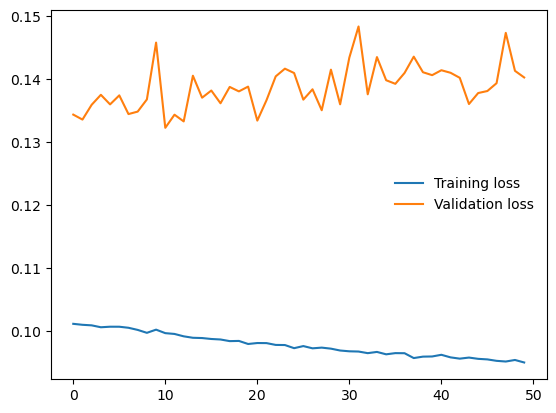

In [118]:
# Trained for 651min ~ 10hr51min. This was 50 epochs
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Validation loss')
plt.legend(frameon=False)

In [155]:
state_dict = torch.load('ch_point.pth')
model.load_state_dict(state_dict)

C:\Users\Cesaire\AppData\Local\Temp\ipykernel_48288\1287654157.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('ch_point.pth')


<All keys matched successfully>

In [198]:
f, l = next(iter(train_loader))
model.eval()
with torch.no_grad():
    o = model(f)
v = torch.tensor([1 if e > 0.0 else 0 for e in o])
v = v.view(l.shape)
print(v.shape)
print(sum (l == v))

torch.Size([128, 1])
tensor([128])


In [ ]:
print(f"Highest accuracy: {acc:.4f}")
print(f"Saved epoch: {saved_epoch}")

Highest accuracy: 0.9548
